In [13]:

!pip install duckdb-engine jupysql --quiet
%load_ext sql
%sql duckdb://



The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [16]:
%%sql
WITH Calculated_Prices AS (
    SELECT
        city,
        subregion,
        building_type,
        price,
        apartment_area,
        n_rooms,
        (price / apartment_area) AS price_m2,
        AVG(price / apartment_area) OVER(PARTITION BY city, building_type) AS avg_market_price_m2
    -- Dodajemy parametr ignore_errors=true wewnątrz read_csv
    FROM read_csv('sample_data/otodom_apartments.csv', ignore_errors=true)
    WHERE price > 0 AND apartment_area > 0 AND city IS NOT NULL AND building_type IS NOT NULL
)
SELECT
    city AS Miasto,
    building_type AS Typ_Budynku,
    n_rooms AS Pokoje,
    ROUND(apartment_area, 1) AS Metraz,
    price AS Cena_Calkowita,
    ROUND(price_m2, 0) AS Cena_za_M2,
    ROUND(avg_market_price_m2, 0) AS Srednia_Rynkowa_M2,
    ROUND(((price_m2 - avg_market_price_m2) / avg_market_price_m2) * 100, 1) AS Odchylenie_Procentowe
FROM Calculated_Prices
WHERE price_m2 < (avg_market_price_m2 * 0.80)
ORDER BY Odchylenie_Procentowe ASC
LIMIT 10;

Running query in 'duckdb://'

RuntimeError: (duckdb.duckdb.TransactionException) TransactionContext Error: Current transaction is aborted (please ROLLBACK)
[SQL: WITH Calculated_Prices AS (
    SELECT
        city,
        subregion,
        building_type,
        price,
        apartment_area,
        n_rooms,
        (price / apartment_area) AS price_m2,
        AVG(price / apartment_area) OVER(PARTITION BY city, building_type) AS avg_market_price_m2

    FROM read_csv('sample_data/otodom_apartments.csv', ignore_errors=true)
    WHERE price > 0 AND apartment_area > 0 AND city IS NOT NULL AND building_type IS NOT NULL
)
SELECT
    city AS Miasto,
    building_type AS Typ_Budynku,
    n_rooms AS Pokoje,
    ROUND(apartment_area, 1) AS Metraz,
    price AS Cena_Calkowita,
    ROUND(price_m2, 0) AS Cena_za_M2,
    ROUND(avg_market_price_m2, 0) AS Srednia_Rynkowa_M2,
    ROUND(((price_m2 - avg_market_price_m2) / avg_market_price_m2) * 100, 1) AS Odchylenie_Procentowe
FROM Calculated_Prices
WHERE price_m2 < (avg_market

In [17]:
%sql ROLLBACK;

Running query in 'duckdb://'

Success


In [18]:
%%sql
WITH Calculated_Prices AS (
    SELECT
        city,
        subregion,
        building_type,
        price,
        apartment_area,
        n_rooms,
        (price / apartment_area) AS price_m2,
        AVG(price / apartment_area) OVER(PARTITION BY city, building_type) AS avg_market_price_m2
    -- Dodane auto_detect=true razem z ignore_errors=true
    FROM read_csv('sample_data/otodom_apartments.csv', auto_detect=true, ignore_errors=true)
    WHERE price > 0 AND apartment_area > 0 AND city IS NOT NULL AND building_type IS NOT NULL
)
SELECT
    city AS Miasto,
    building_type AS Typ_Budynku,
    n_rooms AS Pokoje,
    ROUND(apartment_area, 1) AS Metraz,
    price AS Cena_Calkowita,
    ROUND(price_m2, 0) AS Cena_za_M2,
    ROUND(avg_market_price_m2, 0) AS Srednia_Rynkowa_M2,
    ROUND(((price_m2 - avg_market_price_m2) / avg_market_price_m2) * 100, 1) AS Odchylenie_Procentowe
FROM Calculated_Prices
WHERE price_m2 < (avg_market_price_m2 * 0.80)
ORDER BY Odchylenie_Procentowe ASC
LIMIT 10;

Running query in 'duckdb://'

Miasto,Typ_Budynku,Pokoje,Metraz,Cena_Calkowita,Cena_za_M2,Srednia_Rynkowa_M2,Odchylenie_Procentowe
Iława,block,3,62,69000,1113.0,6892.0,-83.9
Kraków,block,2,39,111111,2849.0,14000.0,-79.6
Gdańsk,block,3,90,220000,2444.0,11092.0,-78.0
Wrocław,apartment,3,58,184000,3172.0,13928.0,-77.2
Sulęcin,block,3,49,69210,1412.0,5304.0,-73.4
Olsztyn,tenement,2,44,100000,2273.0,7830.0,-71.0
Poznań,block,3,61,198000,3246.0,11020.0,-70.5
Poznań,block,2,52,169000,3250.0,11020.0,-70.5
Toruń,block,3,49,130000,2653.0,8818.0,-69.9
Wrocław,block,3,74,278999,3770.0,12332.0,-69.4


In [19]:
%%sql
SELECT
    province AS Wojewodztwo,
    building_type AS Typ_Budynku,
    COUNT(*) AS Liczba_Ofert,
    ROUND(AVG(price), 0) AS Srednia_Cena,
    ROUND(AVG(price / apartment_area), 0) AS Srednia_Cena_za_m2,
    ROUND(AVG(apartment_area), 1) AS Srednia_Powierzchnia
FROM read_csv('sample_data/otodom_apartments.csv', auto_detect=true, ignore_errors=true)
WHERE province IS NOT NULL AND building_type IS NOT NULL AND apartment_area > 0
GROUP BY province, building_type
HAVING COUNT(*) >= 5
ORDER BY Srednia_Cena_za_m2 DESC
LIMIT 15;

Running query in 'duckdb://'

Wojewodztwo,Typ_Budynku,Liczba_Ofert,Srednia_Cena,Srednia_Cena_za_m2,Srednia_Powierzchnia
mazowieckie,tenement,285,720855.0,16549.0,44.9
malopolskie,apartment,513,728657.0,15935.0,48.1
mazowieckie,apartment,826,728024.0,15502.0,49.2
malopolskie,tenement,57,641858.0,15102.0,44.7
zachodniopomorskie,apartment,405,657702.0,15097.0,46.3
pomorskie,apartment,483,648770.0,14495.0,46.8
malopolskie,block,1959,645151.0,13269.0,49.9
mazowieckie,block,3511,631767.0,13208.0,49.7
dolnoslaskie,apartment,1243,675294.0,13172.0,53.5
pomorskie,tenement,142,616326.0,12390.0,51.8


In [20]:
%%sql
SELECT
    CASE EXTRACT(DOW FROM CAST(utc_created_at AS TIMESTAMP))
        WHEN 0 THEN '7. Niedziela'
        WHEN 1 THEN '1. Poniedziałek'
        WHEN 2 THEN '2. Wtorek'
        WHEN 3 THEN '3. Środa'
        WHEN 4 THEN '4. Czwartek'
        WHEN 5 THEN '5. Piątek'
        WHEN 6 THEN '6. Sobota'
    END AS Dzien_Tygodnia,
    COUNT(*) AS Liczba_Nowych_Ofert,
    ROUND(AVG(price), 0) AS Srednia_Cena_Wprowadzona
FROM read_csv('sample_data/otodom_apartments.csv', auto_detect=true, ignore_errors=true)
WHERE utc_created_at IS NOT NULL
GROUP BY EXTRACT(DOW FROM CAST(utc_created_at AS TIMESTAMP))
ORDER BY Dzien_Tygodnia;

Running query in 'duckdb://'

Dzien_Tygodnia,Liczba_Nowych_Ofert,Srednia_Cena_Wprowadzona
1. Poniedziałek,4465,557957.0
2. Wtorek,12154,545244.0
3. Środa,5278,546012.0
4. Czwartek,11852,545140.0


In [21]:
%%sql
WITH Priced_Apartments AS (
    SELECT
        city,
        building_type,
        n_rooms,
        apartment_area,
        (price / apartment_area) AS price_m2,
        -- Obliczamy pozycję procentową ceny za m2 w ramach danego miasta
        PERCENT_RANK() OVER(PARTITION BY city ORDER BY (price / apartment_area)) AS price_rank
    FROM read_csv('sample_data/otodom_apartments.csv', auto_detect=true, ignore_errors=true)
    WHERE price > 0 AND apartment_area > 0 AND city IS NOT NULL
),
Segmented_Market AS (
    SELECT *,
        CASE
            WHEN price_rank >= 0.90 THEN '3. PREMIUM / LUXURY'
            WHEN price_rank >= 0.25 THEN '2. MEDIUM MARKET'
            ELSE '1. BUDGET'
        END AS market_segment
    FROM Priced_Apartments
)
-- Teraz sprawdzamy, jaki jest średni metraż i liczba pokoi w segmencie luksusowym per miasto
SELECT
    city AS Miasto,
    market_segment AS Segment,
    COUNT(*) AS Liczba_Ofert,
    ROUND(AVG(price_m2), 0) AS Srednia_Cena_m2,
    ROUND(AVG(apartment_area), 1) AS Srednia_Powierzchnia,
    ROUND(AVG(n_rooms), 1) AS Srednia_Liczba_Pokoi
FROM Segmented_Market
WHERE city IN ('Warszawa', 'Kraków', 'Wrocław', 'Poznań', 'Gdańsk')
GROUP BY city, market_segment
ORDER BY city, market_segment DESC;

Running query in 'duckdb://'

Miasto,Segment,Liczba_Ofert,Srednia_Cena_m2,Srednia_Powierzchnia,Srednia_Liczba_Pokoi
Gdańsk,3. PREMIUM / LUXURY,298,18919.0,38.6,1.8
Gdańsk,2. MEDIUM MARKET,1937,11557.0,47.0,2.4
Gdańsk,1. BUDGET,745,9072.0,61.3,3.4
Kraków,3. PREMIUM / LUXURY,262,20602.0,35.9,1.7
Kraków,2. MEDIUM MARKET,1697,14809.0,47.6,2.3
Kraków,1. BUDGET,657,11222.0,59.9,2.9
Poznań,3. PREMIUM / LUXURY,137,15214.0,43.2,2.0
Poznań,2. MEDIUM MARKET,884,11507.0,49.4,2.4
Poznań,1. BUDGET,341,9116.0,62.6,3.0
Warszawa,3. PREMIUM / LUXURY,392,22363.0,36.4,1.7


In [22]:
%%sql
SELECT
    CASE
        WHEN floor = 0 THEN '1. Parter'
        WHEN floor = building_floors_num AND building_floors_num > 2 THEN '3. Ostatnie piętro (Wieżowiec/Blok)'
        ELSE '2. Piętra środkowe'
    END AS Umiejscowienie_Mieszkania,
    COUNT(*) AS Liczba_Ofert,
    ROUND(AVG(price / apartment_area), 0) AS Srednia_Cena_za_m2,
    ROUND(AVG(apartment_area), 1) AS Srednia_Wielkosc
FROM read_csv('sample_data/otodom_apartments.csv', auto_detect=true, ignore_errors=true)
WHERE price > 0 AND apartment_area > 0 AND floor IS NOT NULL AND building_floors_num IS NOT NULL
GROUP BY Umiejscowienie_Mieszkania
ORDER BY Umiejscowienie_Mieszkania;

Running query in 'duckdb://'

Umiejscowienie_Mieszkania,Liczba_Ofert,Srednia_Cena_za_m2,Srednia_Wielkosc
2. Piętra środkowe,16090,11236.0,51.9
3. Ostatnie piętro (Wieżowiec/Blok),3806,10595.0,52.1


In [25]:
%%sql
WITH Clean_Dates AS (
    SELECT
        -- Bezpieczne parsowanie daty w formacie 'YYYY-MM-DD HH:MM:SS'
        strptime(LEFT(utc_created_at, 19), '%Y-%m-%d %H:%M:%S') AS parsed_date
    FROM read_csv('sample_data/otodom_apartments.csv', auto_detect=true, ignore_errors=true)
    WHERE utc_created_at IS NOT NULL
)
SELECT
    MIN(parsed_date) AS Najstarsze_Ogłoszenie,
    MAX(parsed_date) AS Najnowsze_Ogłoszenie,
    COUNT(*) AS Wszystkich_Wierszy
FROM Clean_Dates;

Running query in 'duckdb://'

RuntimeError: (duckdb.duckdb.BinderException) Binder Error: No function matches the given name and argument types 'left(TIMESTAMP, INTEGER_LITERAL)'. You might need to add explicit type casts.
	Candidate functions:
	left(VARCHAR, BIGINT) -> VARCHAR


LINE 4:         strptime(LEFT(utc_created_at, 19), '%Y-%m-%d %H:%M:%S') AS parsed_da...
                         ^
[SQL: WITH Clean_Dates AS (
    SELECT

        strptime(LEFT(utc_created_at, 19), '%Y-%m-%d %H:%M:%S') AS parsed_date
    FROM read_csv('sample_data/otodom_apartments.csv', auto_detect=true, ignore_errors=true)
    WHERE utc_created_at IS NOT NULL
)
SELECT
    MIN(parsed_date) AS Najstarsze_Ogłoszenie,
    MAX(parsed_date) AS Najnowsze_Ogłoszenie,
    COUNT(*) AS Wszystkich_Wierszy
FROM Clean_Dates;]
(Background on this error at: https://sqlalche.me/e/20/f405)


In [26]:
%%sql
SELECT
    MIN(utc_created_at) AS Najstarsze_Ogloszenie,
    MAX(utc_created_at) AS Najnowsze_Ogloszenie,
    COUNT(*) AS Wszystkich_Wierszy
FROM read_csv('sample_data/otodom_apartments.csv', auto_detect=true, ignore_errors=true)
WHERE utc_created_at IS NOT NULL;

Running query in 'duckdb://'

Najstarsze_Ogloszenie,Najnowsze_Ogloszenie,Wszystkich_Wierszy
2023-07-26 16:15:06,2024-01-17 17:02:56,33749


In [27]:
%%sql
SELECT
    CASE EXTRACT(DOW FROM utc_created_at)
        WHEN 0 THEN '7. Niedziela'
        WHEN 1 THEN '1. Poniedziałek'
        WHEN 2 THEN '2. Wtorek'
        WHEN 3 THEN '3. Środa'
        WHEN 4 THEN '4. Czwartek'
        WHEN 5 THEN '5. Piątek'
        WHEN 6 THEN '6. Sobota'
    END AS Dzien_Tygodnia,
    COUNT(*) AS Liczba_Nowych_Ofert
FROM read_csv('sample_data/otodom_apartments.csv', auto_detect=true, ignore_errors=true)
WHERE utc_created_at IS NOT NULL
GROUP BY EXTRACT(DOW FROM utc_created_at)
ORDER BY Dzien_Tygodnia;

Running query in 'duckdb://'

Dzien_Tygodnia,Liczba_Nowych_Ofert
1. Poniedziałek,4465
2. Wtorek,12154
3. Środa,5278
4. Czwartek,11852


In [23]:
%%sql rfg_sezonowosc <<
SELECT
    CASE EXTRACT(DOW FROM CAST(utc_created_at AS TIMESTAMP))
        WHEN 0 THEN '7. Niedziela'
        WHEN 1 THEN '1. Poniedziałek'
        WHEN 2 THEN '2. Wtorek'
        WHEN 3 THEN '3. Środa'
        WHEN 4 THEN '4. Czwartek'
        WHEN 5 THEN '5. Piątek'
        WHEN 6 THEN '6. Sobota'
    END AS Dzien_Tygodnia,
    COUNT(*) AS Liczba_Nowych_Ofert
FROM read_csv('sample_data/otodom_apartments.csv', auto_detect=true, ignore_errors=true)
WHERE utc_created_at IS NOT NULL
GROUP BY EXTRACT(DOW FROM CAST(utc_created_at AS TIMESTAMP))
ORDER BY Dzien_Tygodnia;

Running query in 'duckdb://'

/tmp/ipykernel_2717/2424604237.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_wykres, x='Dzien_Tygodnia', y='Liczba_Nowych_Ofert', palette='Blues_r')


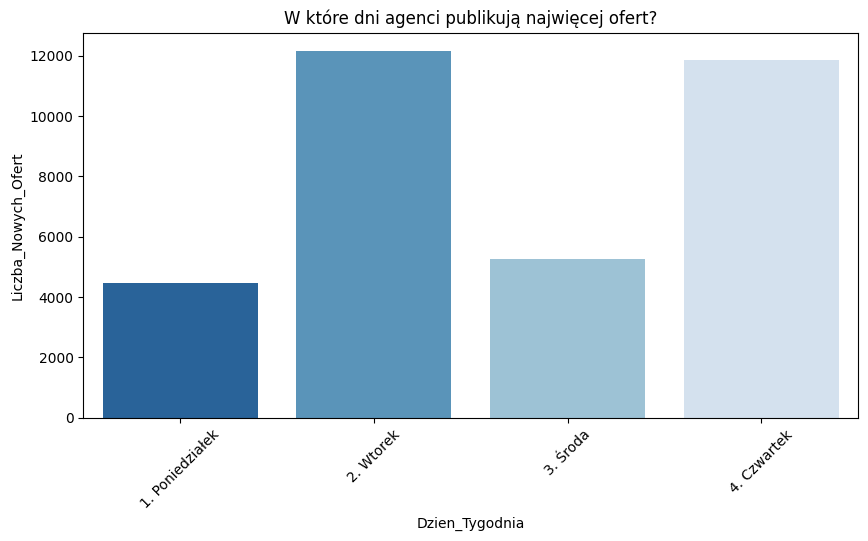

In [24]:
# Wynik z SQL jest teraz zwykłą ramką danych (DataFrame)!
df_wykres = rfg_sezonowosc.DataFrame()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(data=df_wykres, x='Dzien_Tygodnia', y='Liczba_Nowych_Ofert', palette='Blues_r')
plt.title('W które dni agenci publikują najwięcej ofert?')
plt.xticks(rotation=45)
plt.show()

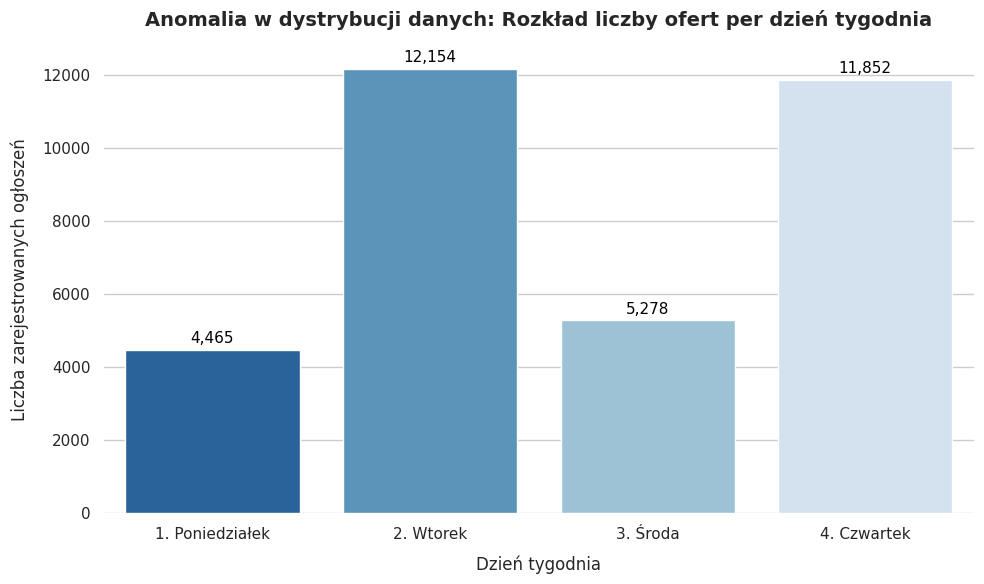

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pobieramy dane z ostatniego zapytania SQL zapisanego w JupySQL
# (Upewnij się, że nad Twoim zapytaniem z dniami tygodnia było np. %%sql df_days <<)
# Jeśli nie zapisałaś do zmiennej, możesz po prostu przekonwertować ostatni wynik:
df_wykres = _  # Podłoga w Jupyter/Colab oznacza "ostatni zwrócony wynik"
df_pandas = df_wykres.DataFrame()

# 2. Ustawienie eleganckiego stylu wizualizacji
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Tworzenie wykresu słupkowego
ax = sns.barplot(
    data=df_pandas,
    x='Dzien_Tygodnia',
    y='Liczba_Nowych_Ofert',
    palette='Blues_r',
    hue='Dzien_Tygodnia',
    legend=False
)

# 4. Dodanie estetycznych detali i tytułu
plt.title('Anomalia w dystrybucji danych: Rozkład liczby ofert per dzień tygodnia', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Dzień tygodnia', fontsize=12, labelpad=10)
plt.ylabel('Liczba zarejestrowanych ogłoszeń', fontsize=12, labelpad=10)

# Dodanie wartości nad słupkami, żeby wykres był czytelny na pierwszy rzut oka
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline',
                fontsize=11, color='black',
                xytext=(0, 5),
                textcoords='offset points')

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()